In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
wines = pd.read_csv("data.csv")
wines.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
wines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [4]:
wines.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
wines.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

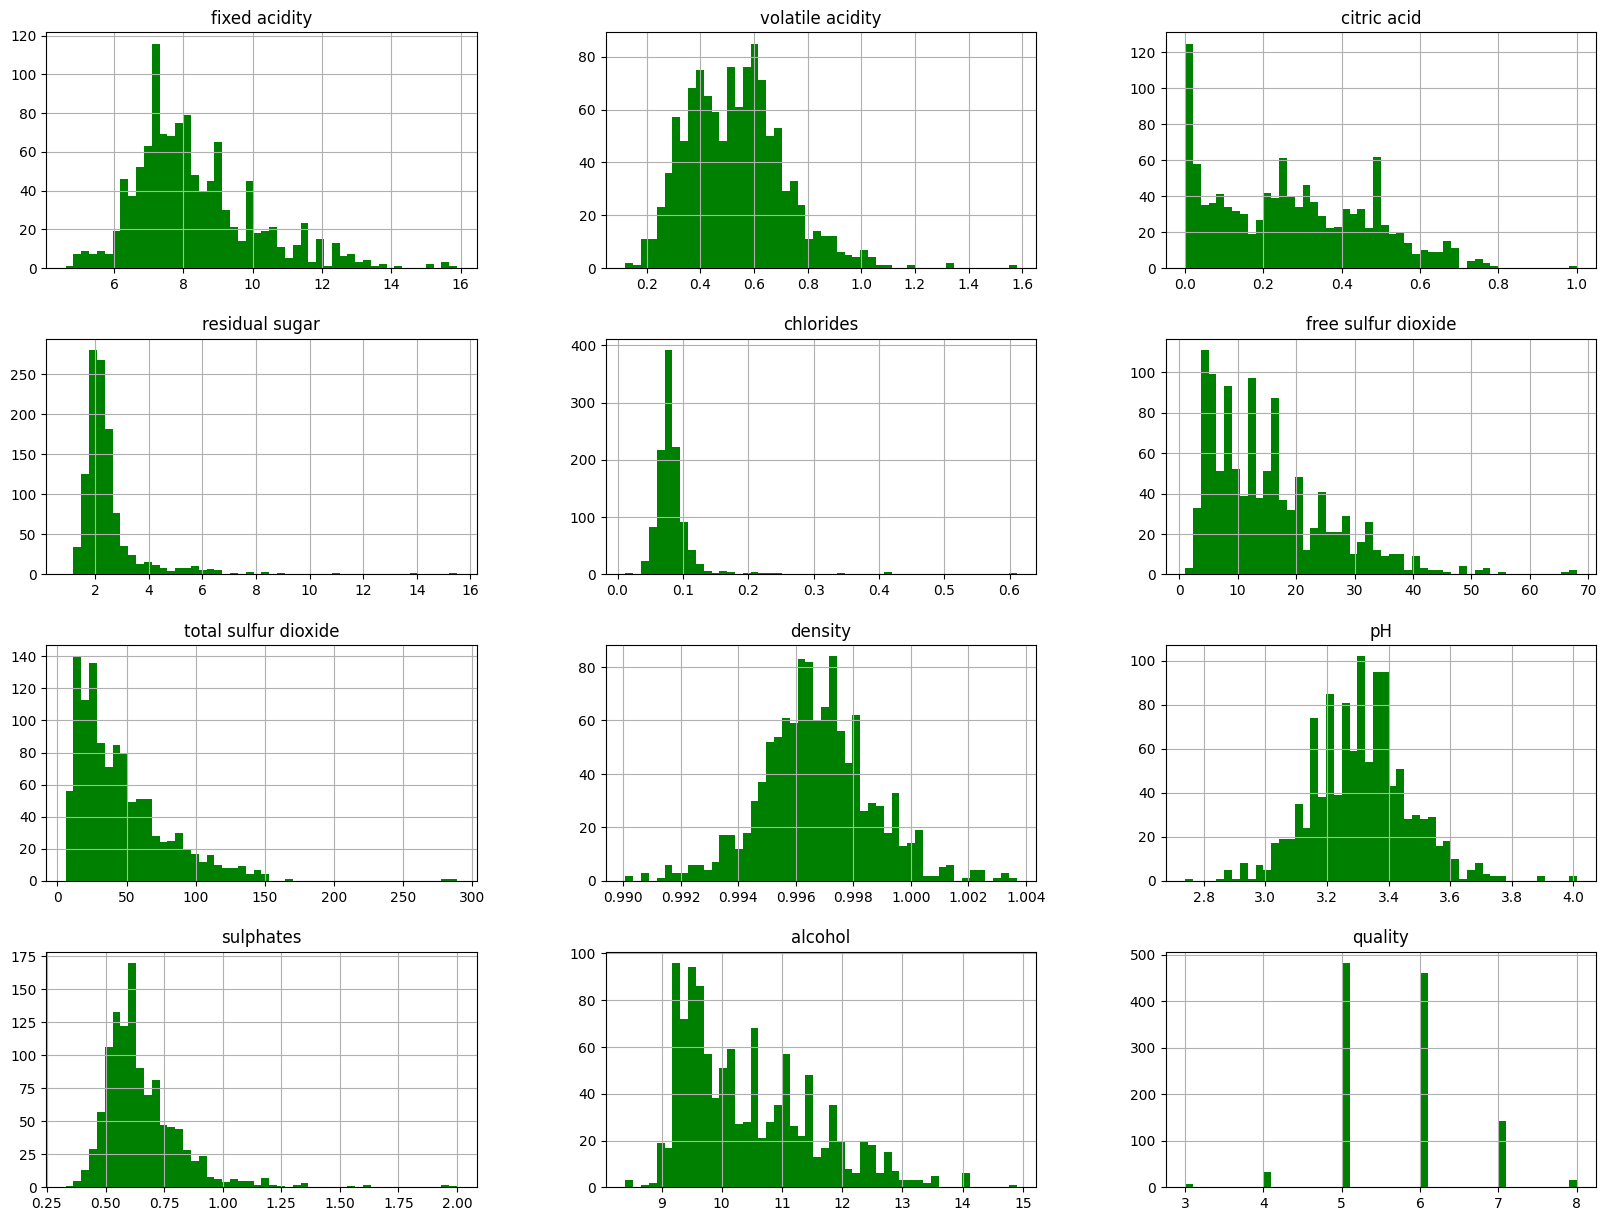

In [6]:
wines.hist(bins=50, figsize=(20,15), color = "green")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X = wines.drop(['quality'], axis=1)
y = wines['quality']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(914, 11)
(229, 11)
(914,)
(229,)


In [8]:
from sklearn.linear_model import ElasticNet

lr = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
lr.fit(X_train, y_train)

,alpha,0.1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def eval_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)

    return rmse, mae, r2

In [11]:
predicted_value = lr.predict(X_test)
predicted_value

array([5.37435233, 5.16545238, 5.44312849, 5.27053155, 6.3435489 ,
       6.50276269, 5.38022614, 5.14683442, 5.6833334 , 5.39358127,
       6.23938354, 5.9610367 , 5.75480196, 6.15231986, 5.88302485,
       5.5684203 , 5.50626094, 5.68343479, 5.46810528, 6.19419985,
       5.77815439, 5.8940966 , 5.18445896, 6.17370545, 5.63292107,
       5.36334678, 6.31870543, 5.85328614, 5.34012199, 5.60236511,
       6.38641014, 5.50789586, 6.43460753, 5.67123999, 5.7332361 ,
       5.22703034, 5.6621904 , 5.83171655, 6.58950683, 5.14605042,
       5.99594562, 5.66049554, 6.5934815 , 5.54716101, 5.45227442,
       5.32331897, 5.87237268, 5.89656681, 5.13500253, 5.92585598,
       6.21070406, 5.58511955, 5.5580085 , 5.66919413, 5.52995406,
       6.22441541, 5.75592784, 5.78409947, 5.49663237, 5.42182775,
       5.52079265, 5.99314618, 5.67674164, 5.9690873 , 6.0367935 ,
       5.54630291, 6.5028523 , 5.24559355, 5.16589249, 6.02165062,
       5.3704786 , 5.33950947, 5.37050825, 6.19834718, 5.54278

In [12]:
(rmse, mae, r2) = eval_metrics(y_test, predicted_value)

print("rmse = ", rmse)
print("mae = ", mae)
print("r2 = ", r2)


rmse =  0.6266607475232402
mae =  0.4995547581531629
r2 =  0.29429873423073927
